# A/B Experiment Analysis

**Experiment:** `{EXPERIMENT_ID}` — *Set in the Parameters cell below*

This notebook follows a rigorous 9-section workflow:

1. Experiment Context
2. Data Extraction
3. Descriptive Statistics
4. Statistical Testing
5. Confidence Intervals
6. Effect Size
7. Power Analysis
8. Business Impact
9. Recommendation

In [26]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ecommerce_analytics.analysis import (
    ExperimentAnalyzer,
    ExperimentCatalog,
    load_experiment_data,
)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)

## Parameters

Change `EXPERIMENT_ID` to analyse a different experiment. Valid IDs: `exp_001` through `exp_010`.

In [27]:
EXPERIMENT_ID = "exp_002"  # <-- change this to analyse a different experiment
ALPHA = 0.05               # significance level
CONFIDENCE = 0.95          # CI confidence level
MIN_PRACTICAL_LIFT = 10.0  # minimum relative lift (%) to be "practically significant"
MONTHLY_TRAFFIC = 100_000  # assumed monthly users for business-impact projection

---

## Section 1 — Experiment Context

In [28]:
catalog = ExperimentCatalog()
meta = catalog.get(EXPERIMENT_ID)

print(f"Experiment : {meta.id} — {meta.name}")
print(f"Hypothesis : {meta.primary_metric} differs between {meta.variants[0]} and {meta.variants[1]}")
print(f"Test type  : {meta.test_type}")
print(f"MDE        : {meta.mde_percent}% ({meta.mde_type})")
print(f"Target n   : {meta.sample_per_variant:,} per variant")
print(f"Rand. unit : {meta.randomization_unit}")
print(f"Split      : {meta.split}")
print(f"Guardrails : {', '.join(meta.guardrail_metrics)}")

Experiment : exp_002 — Payment Installments (6 vs 12 months)
Hypothesis : conversion_rate_high_ticket differs between control_6_installments and treatment_12_installments
Test type  : chi_square
MDE        : 15% (relative)
Target n   : 3,200 per variant
Rand. unit : customer_id
Split      : 50/50
Guardrails : default_rate, approval_rate


In [29]:
print("\nAll 10 experiments in the catalog:")
catalog.summary()


All 10 experiments in the catalog:


,experiment_id,name,primary_metric,test_type,mde_%,sample/variant
0,exp_001,Free Shipping Threshold,conversion_rate,chi_square,10,2450
1,exp_002,Payment Installments (6 vs 12 months),conversion_rate_high_ticket,chi_square,15,3200
2,exp_003,One-Page Checkout,checkout_completion_rate,chi_square,8,3500
3,exp_004,Review Solicitation Timing (3d vs 7d),review_rate,chi_square,20,1800
4,exp_005,Product Recommendations (Personalized vs Popular),add_to_cart_rate,chi_square,12,2700
5,exp_006,Delivery Speed Options (Standard vs Express),conversion_rate,chi_square,5,6200
6,exp_007,Seller Ratings Display (Show vs Hide),conversion_rate_low_rated_sellers,chi_square,10,2500
7,exp_008,Bundle Discounts (3 items for 10% off),items_per_order,t_test,15,350
8,exp_009,Guest Checkout (Guest vs Forced Registration),conversion_rate,chi_square,15,1900
9,exp_010,Dynamic Pricing (Demand-Based),revenue_per_order,t_test,5,1200


---

## Section 2 — Data Extraction

In [30]:
data = load_experiment_data(EXPERIMENT_ID)
print(f"Rows loaded: {len(data):,}")
print(f"Columns    : {list(data.columns)}")
print(f"Date range : {data.get('order_purchase_timestamp', pd.Series()).min()} → "
      f"{data.get('order_purchase_timestamp', pd.Series()).max()}")
data.head()

Rows loaded: 99,441
Columns    : ['assignment_id', 'customer_id', 'customer_state', 'experiment_id', 'experiment_name', 'variant', 'assigned_at', 'assignment_method', 'order_id', 'order_status', 'order_total', 'item_count', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'converted', 'review_score']
Date range : 2016-09-04 21:15:19 → 2018-10-17 17:30:18


,assignment_id,customer_id,customer_state,experiment_id,experiment_name,variant,assigned_at,assignment_method,order_id,order_status,order_total,item_count,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,converted,review_score
0,601b2826-5718-435f-bf3a-0a15865a328a,06b8999e2fba1a1fbc88172c00ba8bc7,SP,exp_002,payment_installments_6_vs_12_months,treatment,2024-02-01T00:00:00Z,hash_based,00e7ee1b050b8499577073aeb2a297a1,delivered,0.0000,0,2017-05-16 15:05:35,2017-05-25 10:35:35,2017-06-05 00:00:00,False,NaN
1,cd90ba6a-e0ad-4c08-8706-59e119e03fce,18955e83d337fd6b2def6b18a428ac77,SP,exp_002,payment_installments_6_vs_12_months,treatment,2024-02-01T00:00:00Z,hash_based,29150127e6685892b6eab3eec79f59c7,delivered,289.0000,1,2018-01-12 20:48:24,2018-01-29 12:41:19,2018-02-06 00:00:00,True,5.0000
2,1f7a2ed8-1704-4189-9123-39abe00c4e6f,4e7b3e00288586ebd08712fdd0374a03,SP,exp_002,payment_installments_6_vs_12_months,treatment,2024-02-01T00:00:00Z,hash_based,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,0.0000,0,2018-05-19 16:07:45,2018-06-14 17:58:51,2018-06-13 00:00:00,False,NaN
3,33679103-c2ec-4c73-a7b9-4608a4fd7da5,b2b6027bc5c5109e529d4dc6358b12c3,SP,exp_002,payment_installments_6_vs_12_months,treatment,2024-02-01T00:00:00Z,hash_based,951670f92359f4fe4a63112aa7306eba,delivered,149.9400,1,2018-03-13 16:06:38,2018-03-28 16:04:25,2018-04-10 00:00:00,True,5.0000
4,0dc03f00-b8d5-4e06-a3b9-76461bf82d14,4f2d8ab171c80ec8364f7c12e35b23ad,SP,exp_002,payment_installments_6_vs_12_months,control,2024-02-01T00:00:00Z,hash_based,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,0.0000,0,2018-07-29 09:51:30,2018-08-09 20:55:48,2018-08-15 00:00:00,False,NaN


In [31]:
# Randomisation balance check — variant split should be ~50/50
variant_counts = data["variant"].value_counts()
print("Variant distribution:")
print(variant_counts)
print(f"\nRatio: {variant_counts.min() / variant_counts.max():.3f}  (ideal ≈ 1.000)")

Variant distribution:
variant
control      49741
treatment    49700
Name: count, dtype: int64

Ratio: 0.999  (ideal ≈ 1.000)


---

## Section 3 — Descriptive Statistics

In [32]:
analyzer = ExperimentAnalyzer(data, meta, alpha=ALPHA, min_lift_pct=MIN_PRACTICAL_LIFT)
desc = analyzer.descriptive_stats()

desc_df = pd.DataFrame({
    "Metric": [
        "Sample size",
        "Conversions",
        "Conversion rate",
        "Revenue — mean",
        "Revenue — median",
        "Revenue — std",
    ],
    "Control": [
        desc["n_control"],
        desc["conversions_control"],
        f"{desc['conversion_rate_control']:.2%}",
        f"${desc['revenue_mean_control']:,.2f}",
        f"${desc['revenue_median_control']:,.2f}",
        f"${desc['revenue_std_control']:,.2f}",
    ],
    "Treatment": [
        desc["n_treatment"],
        desc["conversions_treatment"],
        f"{desc['conversion_rate_treatment']:.2%}",
        f"${desc['revenue_mean_treatment']:,.2f}",
        f"${desc['revenue_median_treatment']:,.2f}",
        f"${desc['revenue_std_treatment']:,.2f}",
    ],
})
desc_df.style.hide(axis="index")

Metric,Control,Treatment
Sample size,49741,49700
Conversions,4017,4622
Conversion rate,8.08%,9.30%
Revenue — mean,$10.72,$12.75
Revenue — median,$0.00,$0.00
Revenue — std,$67.07,$73.64


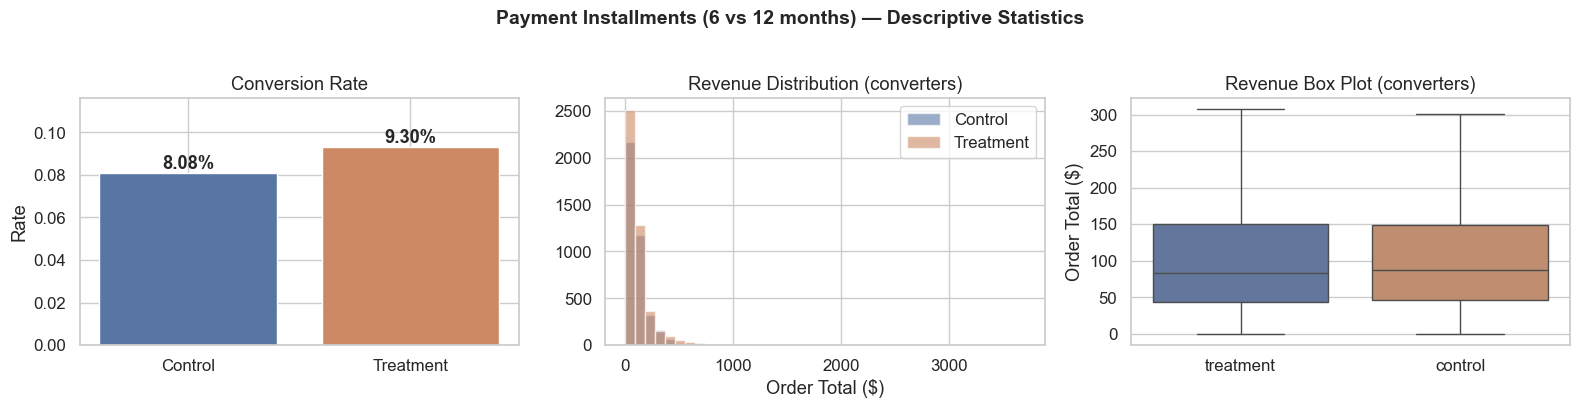

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 3a — Conversion rates bar chart
ax = axes[0]
bars = ax.bar(
    ["Control", "Treatment"],
    [desc["conversion_rate_control"], desc["conversion_rate_treatment"]],
    color=["#5975a4", "#cc8963"],
    edgecolor="white",
)
for bar, val in zip(bars, [desc["conversion_rate_control"], desc["conversion_rate_treatment"]]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f"{val:.2%}", ha="center", fontweight="bold")
ax.set_title("Conversion Rate")
ax.set_ylabel("Rate")
ax.set_ylim(0, max(desc["conversion_rate_control"], desc["conversion_rate_treatment"]) * 1.25)

# 3b — Revenue distribution (converters only)
ax = axes[1]
ctrl_rev = data[(data["variant"] == "control") & (data["converted"])]["order_total"]
treat_rev = data[(data["variant"] == "treatment") & (data["converted"])]["order_total"]
ax.hist(ctrl_rev, bins=40, alpha=0.6, label="Control", color="#5975a4")
ax.hist(treat_rev, bins=40, alpha=0.6, label="Treatment", color="#cc8963")
ax.set_title("Revenue Distribution (converters)")
ax.set_xlabel("Order Total ($)")
ax.legend()

# 3c — Box plot of revenue
ax = axes[2]
plot_data = data[data["converted"]].copy()
sns.boxplot(data=plot_data, x="variant", y="order_total", ax=ax,
            palette=["#5975a4", "#cc8963"], showfliers=False)
ax.set_title("Revenue Box Plot (converters)")
ax.set_xlabel("")
ax.set_ylabel("Order Total ($)")

fig.suptitle(f"{meta.name} — Descriptive Statistics", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---

## Section 4 — Statistical Testing

### Test Decision Tree

| Metric type | Sample ≥ 30? | Normal? | Test selected |
|---|---|---|---|
| Binary (conversion) | Yes | — | Z-test for proportions |
| Binary (conversion) | No | — | Fisher's exact test |
| Continuous (revenue) | Yes | Yes | Welch's t-test |
| Continuous (revenue) | Yes | No | Mann-Whitney U |
| Continuous (revenue) | No | — | Mann-Whitney U |

In [34]:
test_selected = analyzer.select_test()
print(f"Test selected: {test_selected}")
print(f"Rationale    : catalog says test_type='{meta.test_type}'; "
      f"decision tree refined to '{test_selected}'\n")

result = analyzer.run_test()
print(result)
print(f"\nInterpretation: {'Reject' if result.significant else 'Fail to reject'} "
      f"H₀ at α = {ALPHA}.")
if result.significant:
    print("There IS a statistically significant difference between control and treatment.")
else:
    print("There is NO statistically significant difference at this sample size.")

Test selected: z_test
Rationale    : catalog says test_type='chi_square'; decision tree refined to 'z_test'

Z-test for proportions: stat=-6.8519, p=0.0000 (SIGNIFICANT at alpha=0.05)

Interpretation: Reject H₀ at α = 0.05.
There IS a statistically significant difference between control and treatment.


In [35]:
assumptions = analyzer.check_assumptions()
print("Assumption checks:")
for k, v in assumptions.items():
    print(f"  {k}: {v}")

Assumption checks:
  shapiro_control_p: 0.0
  shapiro_treatment_p: 0.0
  normal_control: False
  normal_treatment: False
  levene_p: 0.0
  equal_variance: False


---

## Section 5 — Confidence Intervals

In [36]:
ci = analyzer.confidence_interval(CONFIDENCE)

print(f"Metric          : {ci['metric']}")
print(f"Absolute lift   : {ci['absolute_lift']:.4f}")
print(f"Relative lift   : {ci['relative_lift_pct']:+.2f}%")
print(f"{CONFIDENCE:.0%} CI          : [{ci['ci_lower']:.4f}, {ci['ci_upper']:.4f}]")
print(f"Contains zero?  : {ci['contains_zero']}")
if ci["contains_zero"]:
    print("→ CI contains zero ⇒ cannot rule out no effect.")
else:
    direction = "positive" if ci["ci_lower"] > 0 else "negative"
    print(f"→ CI excludes zero ⇒ confidently {direction} effect.")

Metric          : conversion_rate
Absolute lift   : 0.0122
Relative lift   : +15.10%
95% CI          : [0.0087, 0.0157]
Contains zero?  : False
→ CI excludes zero ⇒ confidently positive effect.


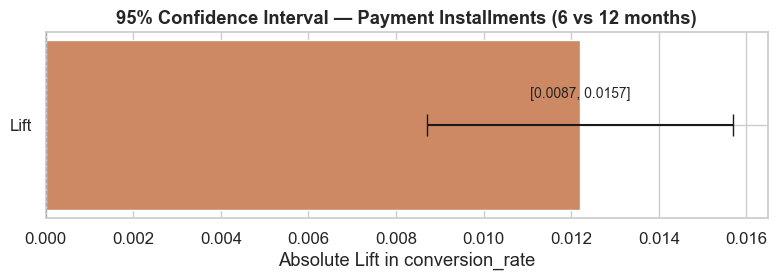

In [37]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.barh("Lift", ci["absolute_lift"], xerr=[[ci["absolute_lift"] - ci["ci_lower"]],
                                            [ci["ci_upper"] - ci["absolute_lift"]]],
        color="#cc8963" if ci["absolute_lift"] > 0 else "#c44e52",
        capsize=8, height=0.4, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel(f"Absolute Lift in {ci['metric']}")
ax.set_title(f"{CONFIDENCE:.0%} Confidence Interval — {meta.name}", fontweight="bold")
ax.annotate(f"[{ci['ci_lower']:.4f}, {ci['ci_upper']:.4f}]",
            xy=(ci["absolute_lift"], 0), xytext=(0, 20),
            textcoords="offset points", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

---

## Section 6 — Effect Size

In [38]:
es = analyzer.effect_size()

effect_metric = "Cohen's h" if es["metric_type"] == "proportion" else "Cohen's d"
effect_val = es.get("cohens_h", es.get("cohens_d"))

print(f"Metric type       : {es['metric_type']}")
print(f"{effect_metric:18s}: {effect_val:.4f}")
print(f"Magnitude         : {es['magnitude']}")
print(f"Absolute diff     : {es['absolute_diff']:.4f}")
print(f"Relative lift     : {es['relative_lift_pct']:+.2f}%")

practically = abs(es["relative_lift_pct"]) >= MIN_PRACTICAL_LIFT
print(f"\nPractically significant (≥ {MIN_PRACTICAL_LIFT}% lift)? "
      f"{'YES' if practically else 'NO'}")

Metric type       : proportion
Cohen's h         : 0.0433
Magnitude         : negligible
Absolute diff     : 0.0122
Relative lift     : +15.10%

Practically significant (≥ 10.0% lift)? YES


---

## Section 7 — Power Analysis

In [39]:
pwr = analyzer.power_analysis()

print(f"Achieved power           : {pwr['achieved_power']}")
print(f"Adequate (≥ 80%)?        : {'YES' if pwr['adequate'] else 'NO'}")
print(f"Planned sample / variant : {pwr['planned_sample_per_variant']:,}")
print(f"Actual n (control)       : {pwr['actual_n_control']:,}")
print(f"Actual n (treatment)     : {pwr['actual_n_treatment']:,}")
print(f"Min n for 80% power      : {pwr['min_sample_for_80pct_power']:,}")

if not pwr["adequate"]:
    shortfall = pwr["min_sample_for_80pct_power"] - min(pwr["actual_n_control"], pwr["actual_n_treatment"])
    if shortfall > 0:
        print(f"\n⚠ Underpowered by ~{shortfall:,} users per variant. "
              "Results may miss real effects (Type II error risk).")
    else:
        print("\nSample exceeds minimum but achieved power is still low — "
              "effect may be smaller than expected.")

Achieved power           : 1.0
Adequate (≥ 80%)?        : YES
Planned sample / variant : 3,200
Actual n (control)       : 49,741
Actual n (treatment)     : 49,700
Min n for 80% power      : 8,467


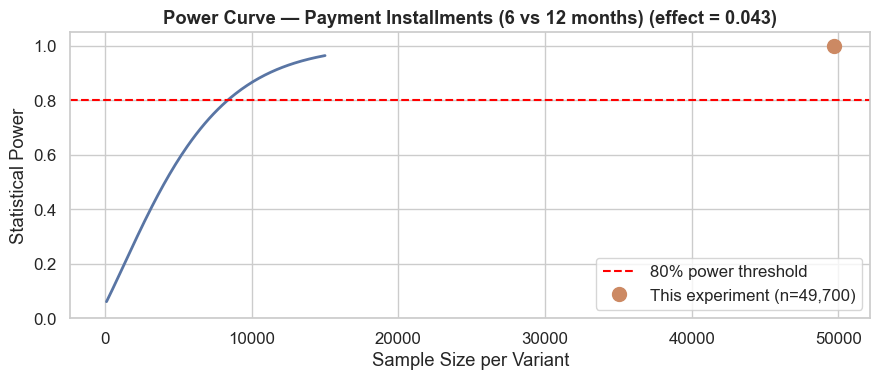

In [40]:
# Power curve: how power changes with sample size for the observed effect
from statsmodels.stats.power import NormalIndPower, TTestIndPower

es_val = abs(es.get("cohens_h", es.get("cohens_d", 0.1)))
if es_val == 0:
    es_val = 0.01

sample_sizes = np.arange(100, 15001, 100)
engine = NormalIndPower() if meta.test_type != "t_test" else TTestIndPower()
powers = [engine.solve_power(effect_size=es_val, nobs1=n, alpha=ALPHA,
                             ratio=1.0, alternative="two-sided") for n in sample_sizes]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sample_sizes, powers, linewidth=2, color="#5975a4")
ax.axhline(0.80, color="red", linestyle="--", label="80% power threshold")
actual_n = min(pwr["actual_n_control"], pwr["actual_n_treatment"])
if pwr["achieved_power"] is not None:
    ax.plot(actual_n, pwr["achieved_power"], "o", color="#cc8963", markersize=10,
            label=f"This experiment (n={actual_n:,})")
ax.set_xlabel("Sample Size per Variant")
ax.set_ylabel("Statistical Power")
ax.set_title(f"Power Curve — {meta.name} (effect = {es_val:.3f})", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

---

## Section 8 — Business Impact

In [41]:
impact = analyzer.business_impact(monthly_traffic=MONTHLY_TRAFFIC)

print(f"Assumptions:")
print(f"  Monthly traffic  : {MONTHLY_TRAFFIC:,} users")
print(f"  Avg rev / user   : ${impact['assumptions']['avg_revenue_per_user']:,.2f}")
print()
print(f"Projected Impact (if treatment launched):")
print(f"  Monthly extra conversions : {impact['monthly_extra_conversions']:,.0f}")
print(f"  Monthly revenue delta     : ${impact['monthly_revenue_impact']:,.2f}")
print(f"  Annual revenue delta      : ${impact['annual_revenue_impact']:,.2f}")
print(f"  Annual CI                 : [${impact['ci_annual_lower']:,.2f}, ${impact['ci_annual_upper']:,.2f}]")

Assumptions:
  Monthly traffic  : 100,000 users
  Avg rev / user   : $12.75

Projected Impact (if treatment launched):
  Monthly extra conversions : 1,220
  Monthly revenue delta     : $15,555.00
  Annual revenue delta      : $186,660.00
  Annual CI                 : [$133,110.00, $240,210.00]


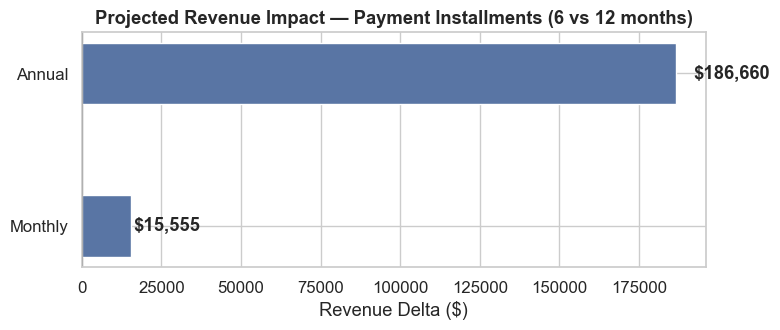

In [42]:
fig, ax = plt.subplots(figsize=(8, 3.5))
labels = ["Monthly", "Annual"]
values = [impact["monthly_revenue_impact"], impact["annual_revenue_impact"]]
colors = ["#5975a4" if v >= 0 else "#c44e52" for v in values]
bars = ax.barh(labels, values, color=colors, edgecolor="white", height=0.4)
ax.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + abs(bar.get_width()) * 0.03,
            bar.get_y() + bar.get_height() / 2,
            f"${val:,.0f}", va="center", fontweight="bold")
ax.set_title(f"Projected Revenue Impact — {meta.name}", fontweight="bold")
ax.set_xlabel("Revenue Delta ($)")
plt.tight_layout()
plt.show()

---

## Section 9 — Recommendation

In [43]:
rec = analyzer.recommendation()

decision_colors = {
    "LAUNCH": "\033[92m",       # green
    "ITERATE": "\033[93m",      # yellow
    "INCONCLUSIVE": "\033[94m", # blue
    "ABANDON": "\033[91m",      # red
}
reset = "\033[0m"
color = decision_colors.get(rec["decision"], "")

print(f"Decision: {color}{rec['decision']}{reset}")
print(f"\nReasoning: {rec['reasoning']}")
print(f"\nChecklist:")
print(f"  Statistically significant : {'✓' if rec['statistically_significant'] else '✗'}")
print(f"  Practically significant   : {'✓' if rec['practically_significant'] else '✗'}")
print(f"  Positive direction        : {'✓' if rec['positive_direction'] else '✗'}")
print(f"  Adequate power            : {'✓' if rec['adequate_power'] else '✗'}")

Decision: LAUNCH

Reasoning: Statistically significant (p=0.0000), practically meaningful (+15.1% lift), and positive direction.

Checklist:
  Statistically significant : ✓
  Practically significant   : ✓
  Positive direction        : ✓
  Adequate power            : ✓


---

## Full Report Summary

In [44]:
analyzer.summary_table().T

,0
experiment_id,exp_002
experiment_name,Payment Installments (6 vs 12 months)
n_control,49741
n_treatment,49700
cr_control,0.0808
cr_treatment,0.0930
p_value,0.0000
significant,True
relative_lift_%,15.1000
ci_lower,0.0087


---

## Cross-Experiment Comparison

Run all 10 experiments through the framework and compare results side by side.

In [45]:
all_summaries = []
for exp_id in catalog.list_ids():
    try:
        exp_data = load_experiment_data(exp_id)
        exp_meta = catalog.get(exp_id)
        exp_analyzer = ExperimentAnalyzer(exp_data, exp_meta, alpha=ALPHA)
        all_summaries.append(exp_analyzer.summary_table())
    except Exception as e:
        print(f"  {exp_id}: skipped ({e})")

if all_summaries:
    comparison = pd.concat(all_summaries, ignore_index=True)
    comparison

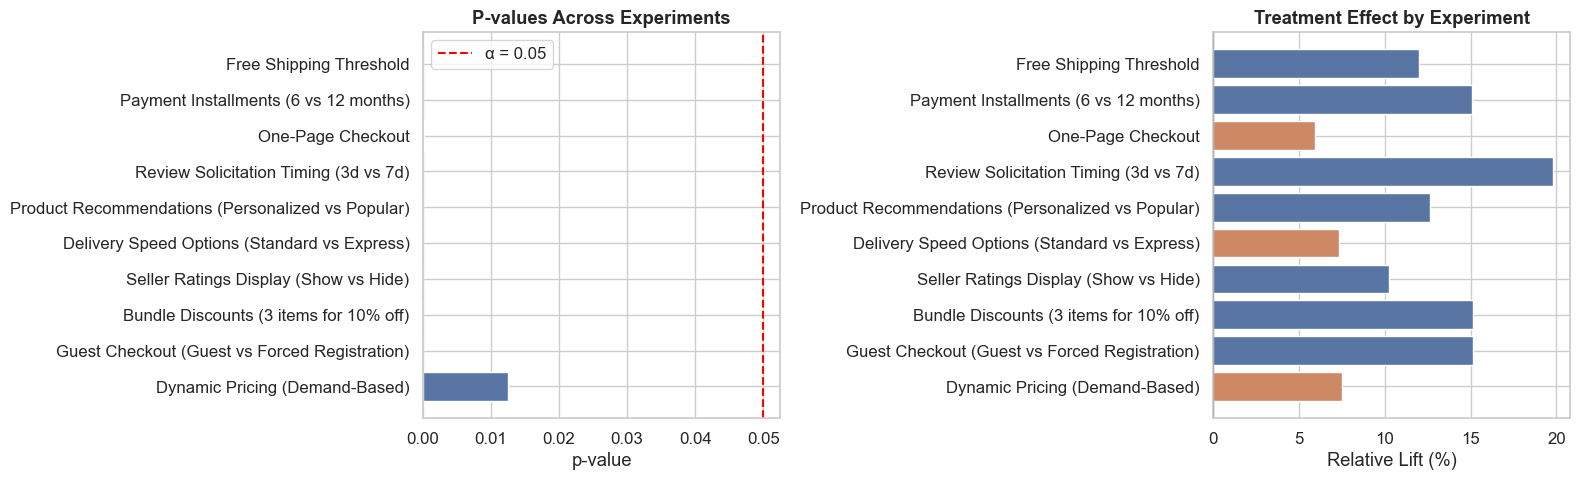

In [46]:
if all_summaries:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # P-values across experiments
    ax = axes[0]
    colors_p = ["#5975a4" if p < ALPHA else "#c44e52" for p in comparison["p_value"]]
    ax.barh(comparison["experiment_name"], comparison["p_value"], color=colors_p, edgecolor="white")
    ax.axvline(ALPHA, color="red", linestyle="--", label=f"α = {ALPHA}")
    ax.set_xlabel("p-value")
    ax.set_title("P-values Across Experiments", fontweight="bold")
    ax.legend()
    ax.invert_yaxis()

    # Relative lift with CIs
    ax = axes[1]
    colors_lift = ["#5975a4" if d == "LAUNCH" else "#cc8963" if d == "ITERATE"
                   else "#c44e52" for d in comparison["decision"]]
    ax.barh(comparison["experiment_name"], comparison["relative_lift_%"],
            color=colors_lift, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Relative Lift (%)")
    ax.set_title("Treatment Effect by Experiment", fontweight="bold")
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

### Multiple Testing Correction

When evaluating many experiments simultaneously, apply Benjamini-Hochberg FDR correction to control false discovery rate.

In [47]:
from ecommerce_analytics.analysis.stats_framework import correct_multiple_tests

if all_summaries:
    correction = correct_multiple_tests(comparison["p_value"].tolist(), method="fdr_bh", alpha=ALPHA)
    correction.index = comparison["experiment_name"].values
    correction["decision_after_correction"] = correction["reject_null"].map(
        {True: "Significant", False: "Not significant"}
    )
    correction

---

## Analysis Workflow Checklist

| # | Step | Status |
|---|------|--------|
| 1 | Load data from BigQuery / local | Done (Section 2) |
| 2 | Verify randomisation balance | Done (Section 2) |
| 3 | Check sample sizes adequate | Done (Section 7) |
| 4 | Run descriptive statistics | Done (Section 3) |
| 5 | Perform hypothesis test | Done (Section 4) |
| 6 | Calculate confidence intervals | Done (Section 5) |
| 7 | Assess effect size | Done (Section 6) |
| 8 | Check power | Done (Section 7) |
| 9 | Apply multiple testing correction | Done (Cross-Experiment) |
| 10 | Interpret results | Done (Section 9) |
| 11 | Make recommendation | Done (Section 9) |

## Common Pitfalls Avoided

| Pitfall | How We Avoid It |
|---|---|
| **Peeking** | Pre-defined sample sizes from catalog; power analysis validates adequacy |
| **HARKing** | Hypothesis stated in Section 1 before looking at data |
| **P-hacking** | Decision tree selects ONE test; no shopping across tests |
| **Multiple testing** | Benjamini-Hochberg FDR correction applied across all 10 experiments |
| **Statistical ≠ practical** | Separate checks: p-value AND minimum lift threshold |
| **Assumption violations** | Shapiro-Wilk and Levene tests checked; non-parametric fallback used |